In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = r"C:\Users\sneha\SupplyChainForecasting\data\raw\train (1).parquet"

df = pd.read_parquet(file_path)

print("Shape:", df.shape)
df.head()

Shape: (7869549, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,activity_flag,discount,holiday_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,2,25,62,31,54,2025-04-30,0.9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.2, ...",5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1.0,0,1.4621,20.88,56.32,1.39
1,0,0,2,25,62,31,54,2025-05-01,2.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, ...",10,"[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...",0,1.0,1,1.2773,21.52,57.65,1.63
2,0,0,2,25,62,31,54,2025-05-02,0.9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, ...",7,"[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1.0,1,1.1190,21.88,60.03,1.77
3,0,0,2,25,62,31,54,2025-05-03,1.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.2, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1.0,1,1.8706,22.63,61.44,2.32
4,0,0,2,25,62,31,54,2025-05-04,1.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.2, ...",9,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0,1.0,1,2.1437,21.99,67.06,2.25


In [4]:
print("Rows: ",len(df))
print("Columns: ",len(df.columns))

print("Stores:",df['store_id'].nunique())
print("Cities:", df["city_id"].nunique())

print("\nDate range:")
print(df["dt"].min(), "to", df["dt"].max())

Rows:  7869549
Columns:  19
Stores: 1057
Cities: 18

Date range:
2023-06-05 to 2025-07-13


***UNIVARIATE ANALYSIS***

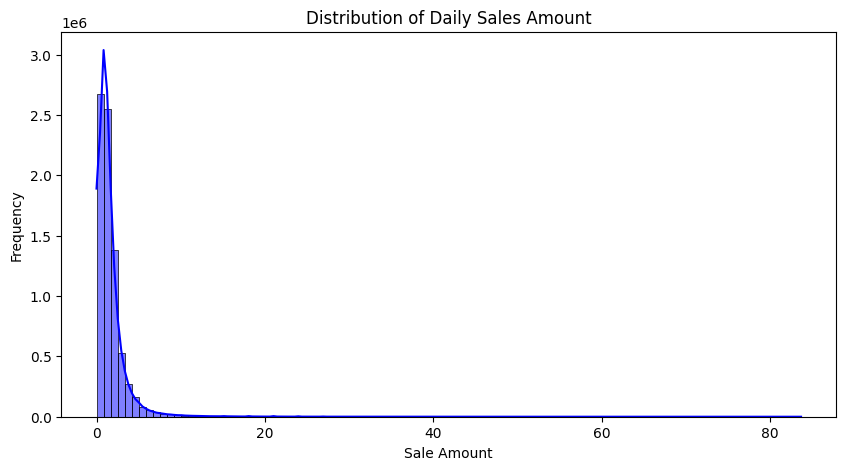

In [ ]:
# HIST PLOT

plt.figure(figsize=(10, 5))

sns.histplot(df["sale_amount"], bins=100, kde=True, color='blue')   #max(sale_amount)=83.7

plt.title("Distribution of Daily Sales Amount")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")

plt.show()

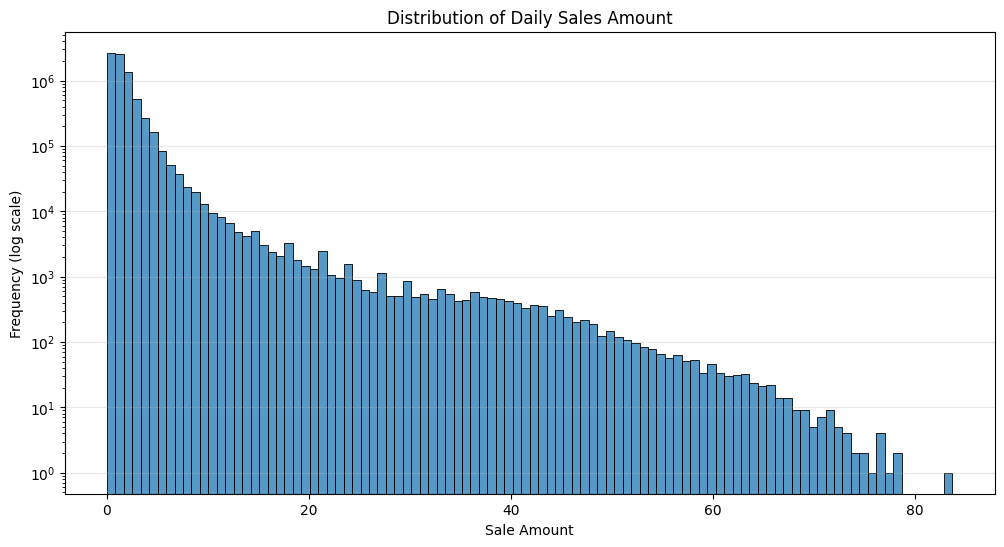

In [ ]:
# HIST PLOT WITH LOG SCALE

plt.figure(figsize=(12, 6))

sns.histplot(df["sale_amount"],bins=100)

plt.yscale("log")

plt.title("Distribution of Daily Sales Amount")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency (log scale)")

plt.grid(axis="y", alpha=0.3)

plt.show()

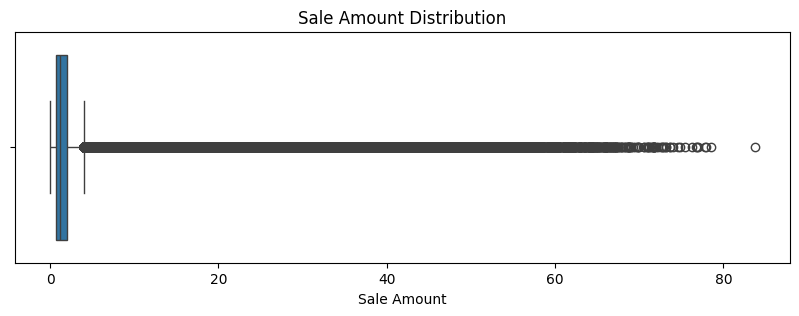

In [7]:
#BOX PLOT OF SALES
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["sale_amount"])

plt.title("Sale Amount Distribution")
plt.xlabel("Sale Amount")

plt.show()

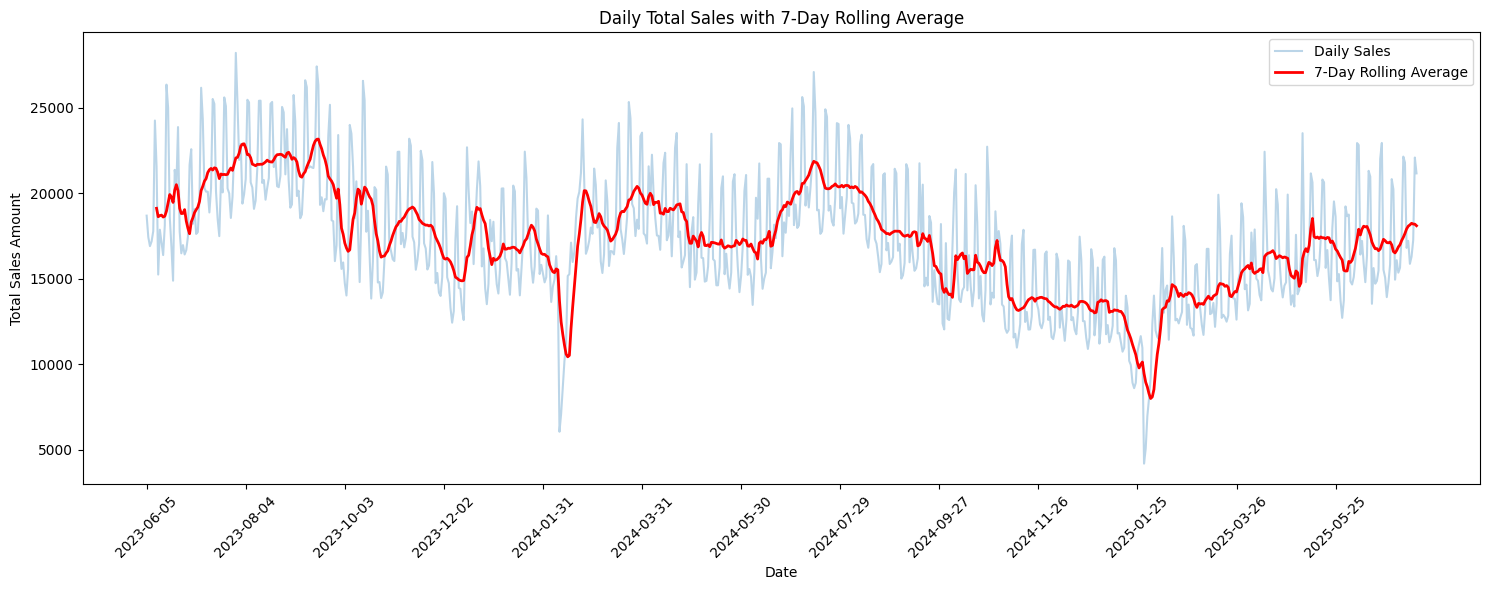

In [ ]:
daily_sales = (df.groupby("dt")["sale_amount"].sum().reset_index())

# 7-day rolling average
daily_sales["rolling_7d"] = (daily_sales["sale_amount"].rolling(7).mean())

plt.figure(figsize=(15, 6))

plt.plot(daily_sales["dt"],daily_sales["sale_amount"],alpha=0.3,label="Daily Sales")

plt.plot(
    daily_sales["dt"],
    daily_sales["rolling_7d"],
    color="red",
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("Daily Total Sales with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Total Sales Amount")

plt.legend()

# Show only a few date labels
plt.xticks(daily_sales["dt"][::60], rotation=45)

plt.tight_layout()
plt.show()

***BIVARIATE ANALYSIS***

In [15]:
df["dt"] = pd.to_datetime(df["dt"])
df['day_of_week'] = df['dt'].dt.day_name()

weekly_sales = (df.groupby('day_of_week')['sale_amount'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']))
print(weekly_sales)

day_of_week
Monday       1.587606
Tuesday      1.609871
Wednesday    1.496093
Thursday     1.506637
Friday       1.613000
Saturday     2.013068
Sunday       1.973796
Name: sale_amount, dtype: float64


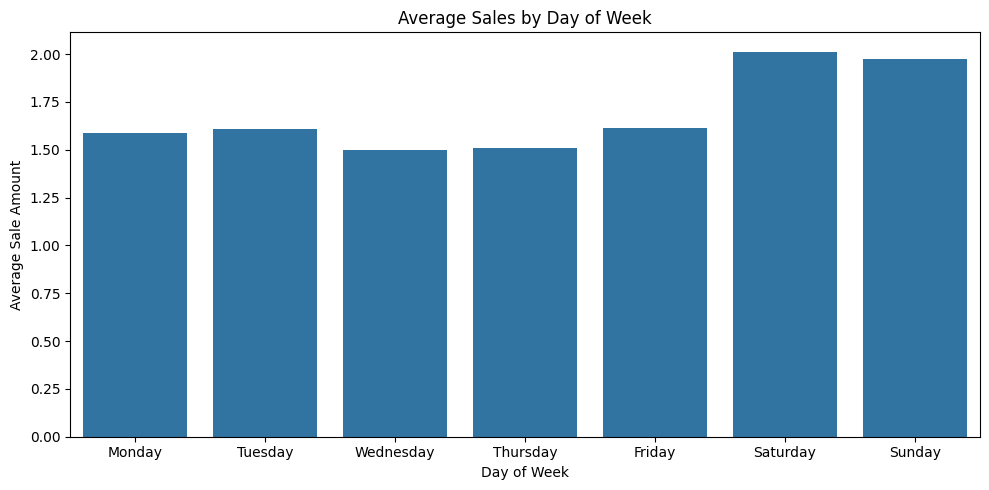

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(x=weekly_sales.index,y=weekly_sales.values)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sale Amount")

plt.tight_layout()
plt.show()

In [50]:
monthly_sales = (
    df.set_index("dt")["sale_amount"].resample("ME").sum())

print(monthly_sales)

dt
2023-06-30    488080.271
2023-07-31    662150.258
2023-08-31    678852.040
2023-09-30    638655.045
2023-10-31    561318.527
2023-11-30    539391.113
2023-12-31    519492.373
2024-01-31    524319.177
2024-02-29    455060.724
2024-03-31    591306.250
2024-04-30    559480.588
2024-05-31    526618.203
2024-06-30    549210.486
2024-07-31    638194.795
2024-08-31    586821.869
2024-09-30    495553.426
2024-10-31    491628.457
2024-11-30    418324.527
2024-12-31    415689.608
2025-01-31    355162.810
2025-02-28    372243.211
2025-03-31    453442.711
2025-04-30    471814.331
2025-05-31    520880.144
2025-06-30    517456.245
2025-07-31    235447.838
Freq: ME, Name: sale_amount, dtype: float64


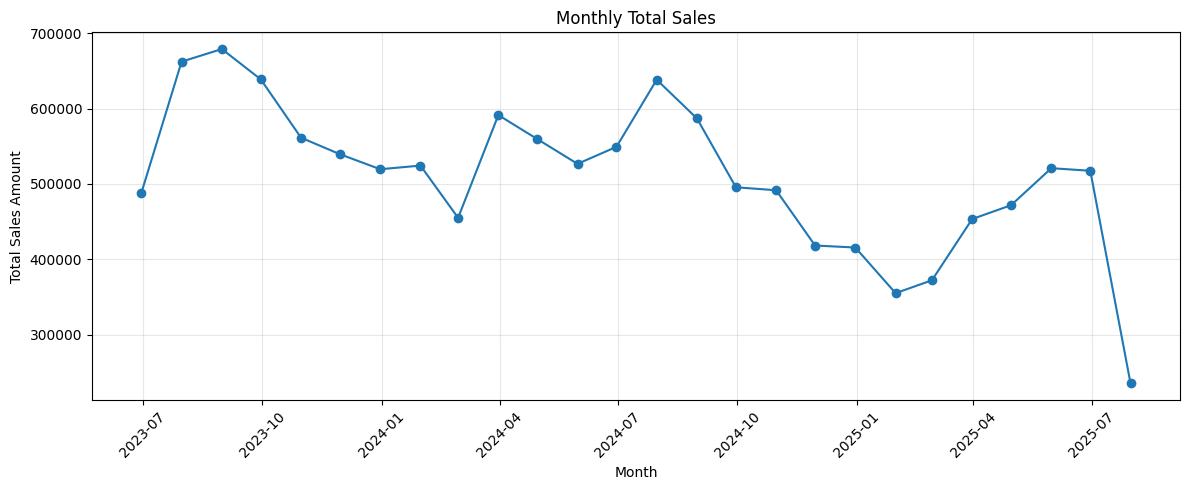

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index,monthly_sales.values, marker="o")

plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

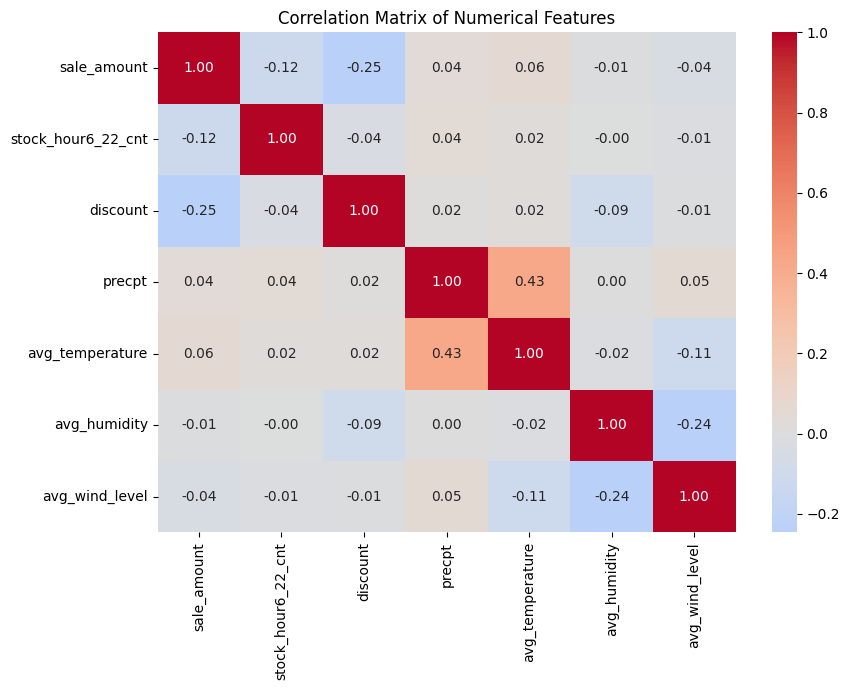

In [28]:
corr_cols = [
    "sale_amount",
    "stock_hour6_22_cnt",
    "discount",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",center=0,fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

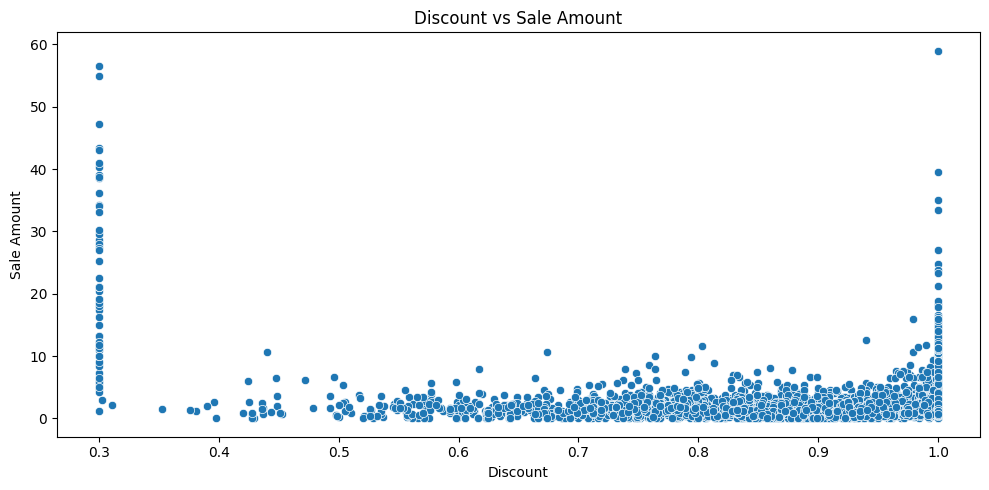

In [34]:
df_sample = df.sample(n=10000, random_state=42)
plt.figure(figsize=(10, 5))
sns.scatterplot(df_sample, x="discount", y="sale_amount")

plt.title("Discount vs Sale Amount")
plt.xlabel("Discount")
plt.ylabel("Sale Amount")

plt.tight_layout()
plt.show()

In [37]:
print(df["stock_hour6_22_cnt"].describe())
print(df["stock_hour6_22_cnt"].value_counts().sort_index().head(20))

count    7.869549e+06
mean     3.546321e+00
std      4.809144e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.000000e+00
max      1.600000e+01
Name: stock_hour6_22_cnt, dtype: float64
stock_hour6_22_cnt
0     4076752
1      260974
2      217938
3      265600
4      386235
5      480535
6      395315
7      267894
8      205493
9      187832
10     190806
11     195093
12     153131
13      90011
14      44837
15      22065
16     429038
Name: count, dtype: int64


In [43]:
stock_sales = df.groupby("stock_hour6_22_cnt")["sale_amount"].mean()
print(stock_sales)

stock_hour6_22_cnt
0     1.731043
1     2.169429
2     2.278445
3     2.198661
4     1.978093
5     1.788433
6     1.686063
7     1.701652
8     1.763087
9     1.805973
10    1.822018
11    1.823545
12    1.714181
13    1.112239
14    0.589407
15    0.375521
16    0.034530
Name: sale_amount, dtype: float64


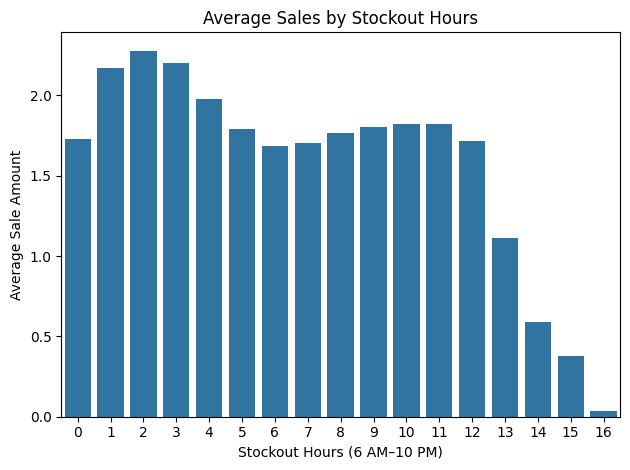

In [44]:
sns.barplot(x=stock_sales.index,y=stock_sales.values)

plt.title("Average Sales by Stockout Hours")
plt.xlabel("Stockout Hours (6 AM–10 PM)")
plt.ylabel("Average Sale Amount")

plt.tight_layout()
plt.show()

In [45]:
holiday_sales = (df.groupby("holiday_flag")["sale_amount"].mean())
print(holiday_sales)

holiday_flag
0    1.564573
1    1.940589
Name: sale_amount, dtype: float64


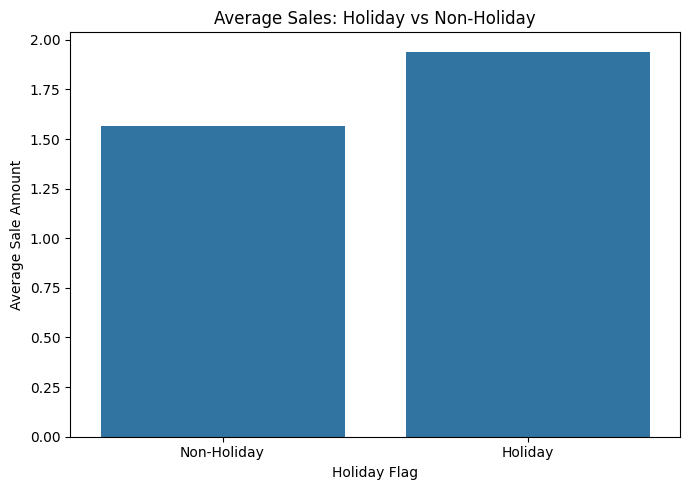

In [46]:
plt.figure(figsize=(7, 5))

sns.barplot(x=holiday_sales.index,y=holiday_sales.values)

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Sale Amount")

plt.xticks([0, 1], ["Non-Holiday", "Holiday"])

plt.tight_layout()
plt.show()

In [47]:
activity_sales = (df.groupby("activity_flag")["sale_amount"].mean())

print(activity_sales)

activity_flag
0    1.600386
1    1.988881
Name: sale_amount, dtype: float64


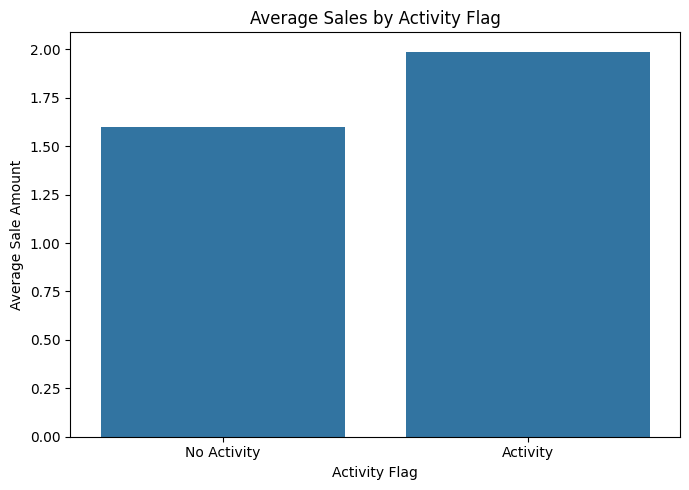

In [48]:
plt.figure(figsize=(7, 5))

sns.barplot( x=activity_sales.index,y=activity_sales.values)

plt.title("Average Sales by Activity Flag")
plt.xlabel("Activity Flag")
plt.ylabel("Average Sale Amount")

plt.xticks([0, 1], ["No Activity", "Activity"])

plt.tight_layout()
plt.show()

***MULTIVARIATE ANALYSIS***

In [55]:
top_stores = df["store_id"].value_counts().head(10).index
top_products = df["product_id"].value_counts().head(10).index

heatmap_data = (
    df[df["store_id"].isin(top_stores) & df["product_id"].isin(top_products)]
    .pivot_table(
        index="store_id",
        columns="product_id",
        values="sale_amount",
        aggfunc="mean"
    )
)

print(heatmap_data)

product_id       6         59        99        132       134       244  \
store_id                                                                 
139              NaN  1.339857       NaN       NaN  6.286604       NaN   
155         1.255676       NaN       NaN  1.936833  7.500562  2.603818   
161         2.214854  2.464993  4.298157  1.997734  5.572638  1.451131   
166         1.386753       NaN  3.979312       NaN       NaN  2.055104   
193              NaN  1.882003  6.033892  2.479832  8.163985       NaN   
223         2.318690       NaN       NaN  2.169188  6.984745  1.710153   
266         0.932172  1.110057  3.669391  1.187121  5.026830       NaN   
274         2.506818  2.760805  4.070260  2.092314  5.664933  1.695599   
575              NaN  2.065814       NaN  1.995567  6.313019       NaN   
576         1.554409  1.834579  4.341974  1.734058  5.326075       NaN   

product_id       277       394       415  
store_id                                  
139         1.581023  3.5

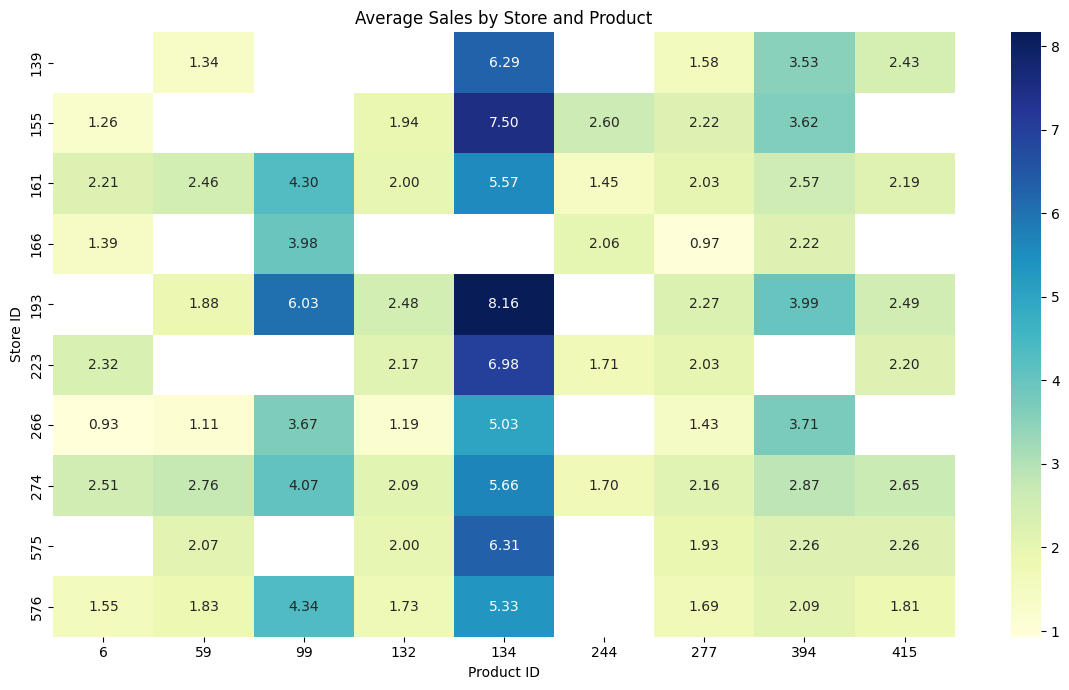

In [56]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f"
)

plt.title("Average Sales by Store and Product")
plt.xlabel("Product ID")
plt.ylabel("Store ID")

plt.tight_layout()
plt.show()